In [16]:
# Import packages
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression # Baseline model
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score  # Metrics loaded
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [17]:
# =========================
# CONFIG
# =========================
DATA_PATH = "data/employee_data.csv"   # change if needed
RANDOM_STATE = 42 # set seed
TARGET_COL = "Current Employee Rating"

# Columns to drop because they are IDs, personally identifying,
# or likely to create leakage / be unhelpful for baseline
DROP_COLS = [
    "EmpID",
    "FirstName",
    "LastName",
    "StartDate",
    "ExitDate",
    "Title",
    "Supervisor",
    "ADEmail",
    "BusinessUnit",
    "EmployeeStatus",
    "TerminationType",
    "TerminationDescription",
    "DOB",
    "DateofHire",
    "Performance Score",   # leakage / close to target / Gonna be too correlated
]

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


# =========================
# HELPER FUNCTIONS
# =========================
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df


def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # handle likely date columns if they exist
    possible_date_cols = ["DOB", "DateofHire", "StartDate", "ExitDate"]
    for col in possible_date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # age
    if "DOB" in df.columns:
        reference_date = pd.Timestamp("2025-01-01")
        df["Age_Years"] = ((reference_date - df["DOB"]).dt.days / 365.25).round(2)

    # tenure
    if "DateofHire" in df.columns:
        reference_date = pd.Timestamp("2025-01-01")
        df["Tenure_Days"] = (reference_date - df["DateofHire"]).dt.days

    # active flag
    if "EmployeeStatus" in df.columns:
        df["Is_Active"] = (df["EmployeeStatus"].astype(str).str.lower() == "active").astype(int)

    return df


def safe_drop_columns(df: pd.DataFrame, cols_to_drop: list) -> pd.DataFrame:
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=existing_cols)


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return preprocessor


def evaluate_classification(y_true, y_pred) -> dict:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")

    return {
        "accuracy": float(acc),
        "f1_weighted": float(f1),
        "precision_weighted": float(precision),
        "recall_weighted": float(recall),
    }

Current Employee Rating
3    0.510000
2    0.170000
4    0.139667
1    0.090333
5    0.090000
Name: proportion, dtype: float64


/var/folders/90/cwb_ycfx3g1cp7q2t1rv6g6m0000gn/T/ipykernel_14360/1689148746.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/90/cwb_ycfx3g1cp7q2t1rv6g6m0000gn/T/ipykernel_14360/1689148746.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


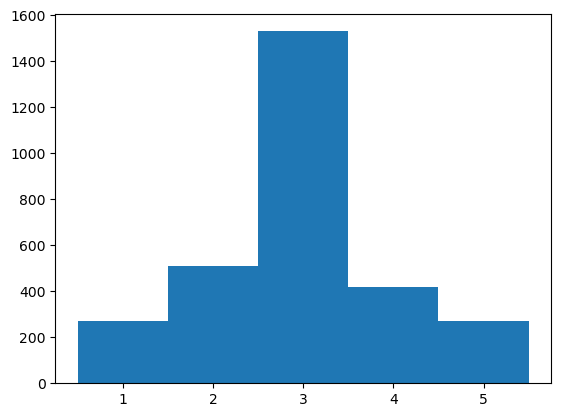

=== BASELINE VALIDATION RESULTS ===
Validation ACC: 0.4933
Validation F1:  0.3719
Validation Precision:  0.3283
Validation Recall: 0.4933
Runtime (seconds): 0.4621
Test set has been created and held out. Do not use it during search phase.


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [19]:
# =========================
# MAIN
# =========================
def main():
    start_time = time.time()

    # 1. Load data
    df = pd.read_csv(DATA_PATH)

    # 2. Parse and feature engineer (Cleaning data + mutate data)
    df = parse_dates(df)
    df = engineer_features(df)

    # 3. Drop rows with missing target
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")

    df = df[df[TARGET_COL].notna()].copy() # Check validation

    # 4. Define X and y
    y = df[TARGET_COL]
    X = safe_drop_columns(df, DROP_COLS + [TARGET_COL])

    # Also remove any datetime columns after feature engineering because we dont need them anymore
    datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns.tolist()
    if datetime_cols:
        X = X.drop(columns=datetime_cols)

    # (Special) Check the distribution of target variable => Normal dist?
    print(df[TARGET_COL].value_counts(normalize=True))
    
    plt.hist(df[TARGET_COL], bins=[0.5,1.5,2.5,3.5,4.5,5.5])
    plt.xticks([1,2,3,4,5])
    plt.show()
    
    # 5. Deterministic split
    # 70 train / 15 val / 15 test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.15, random_state=RANDOM_STATE
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.1764705882,  # gives ~15% of full sample
        random_state=RANDOM_STATE
    )

    X_train.to_csv("data/processed/X_train.csv")
    y_train.to_csv("data/processed/y_train.csv")
    X_val.to_csv("data/processed/X_val.csv")
    y_val.to_csv("data/processed/y_val.csv")

    # 6. Build preprocessor + model
    preprocessor = build_preprocessor(X_train)

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("clf", LogisticRegression(max_iter=1000, multi_class="auto")),
        ]
    )

    # 7. Train
    model.fit(X_train, y_train)

    # 8. Validate
    val_preds = model.predict(X_val)
    
    val_metrics = evaluate_classification(y_val, val_preds)


    runtime_seconds = time.time() - start_time # Check timing

    # 9. Print stable evaluator output
    print("=== BASELINE VALIDATION RESULTS ===")
    print(f"Validation ACC: {val_metrics['accuracy']:.4f}")
    print(f"Validation F1:  {val_metrics['f1_weighted']:.4f}")
    print(f"Validation Precision:  {val_metrics['precision_weighted']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_weighted']:.4f}")
    print(f"Runtime (seconds): {runtime_seconds:.4f}")
    print("Test set has been created and held out. Do not use it during search phase.")

    # 10. Save split sizes for reproducibility
    split_info = {
        "random_state": RANDOM_STATE,
        "target_column": TARGET_COL,
        "n_total": int(len(df)),
        "n_train": int(len(X_train)),
        "n_val": int(len(X_val)),
        "n_test": int(len(X_test)),
        "test_set_policy": "Locked and not used during search phase.",
    }

    with open(RESULTS_DIR / "split_info.json", "w") as f:
        json.dump(split_info, f, indent=2)

    # 11. Save baseline metrics
    output_metrics = {
        "model": "LogisticRegression",
        "validation_metrics": val_metrics,
        "runtime_seconds": runtime_seconds,
    }

    with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
        json.dump(output_metrics, f, indent=2)

    # 12. Save first experiment log entry
    log_row = pd.DataFrame(
        [{
            "experiment_id": 1,
            "model": "LinearRegression",
            "target": TARGET_COL,
            "validation_metric": "accuracy",
            "validation_accuracy": val_metrics["accuracy"],
            "validation_precision": val_metrics["precision_weighted"],
            "validation_recall": val_metrics["recall_weighted"],
            "runtime_seconds": runtime_seconds,
            "random_state": RANDOM_STATE,
            "notes": "Week 2 reproducible baseline run"
        }]
    )

    log_path = RESULTS_DIR / "experiment_log.csv"
    if log_path.exists():
        old_log = pd.read_csv(log_path)
        full_log = pd.concat([old_log, log_row], ignore_index=True)
    else:
        full_log = log_row

    full_log.to_csv(log_path, index=False)

    # 13. Save locked test set indices
    test_indices = pd.DataFrame({"test_index": X_test.index})
    test_indices.to_csv(RESULTS_DIR / "locked_test_indices.csv", index=False)


if __name__ == "__main__":
    main()
